## Linear Dataset → Linear Kernel

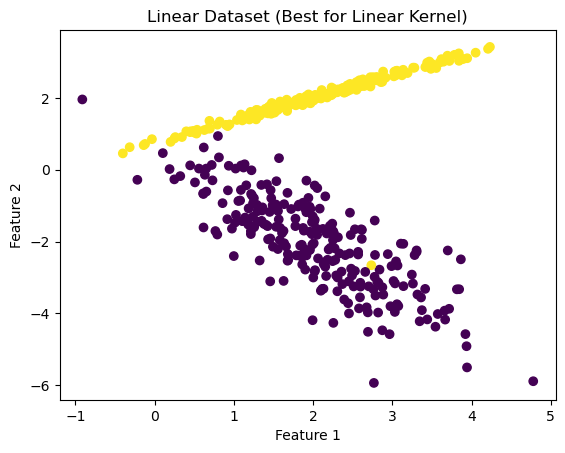

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Generate linearly separable dataset
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

# Plot dataset
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Linear Dataset (Best for Linear Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Polynomial Dataset → Polynomial Kernel

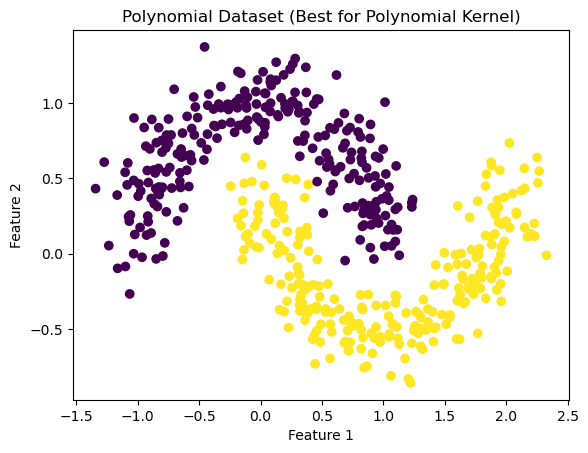

In [2]:
from sklearn.datasets import make_moons

# Generate moon-shaped dataset
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)

# Plot dataset
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Polynomial Dataset (Best for Polynomial Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## Circular Dataset → RBF Kernel

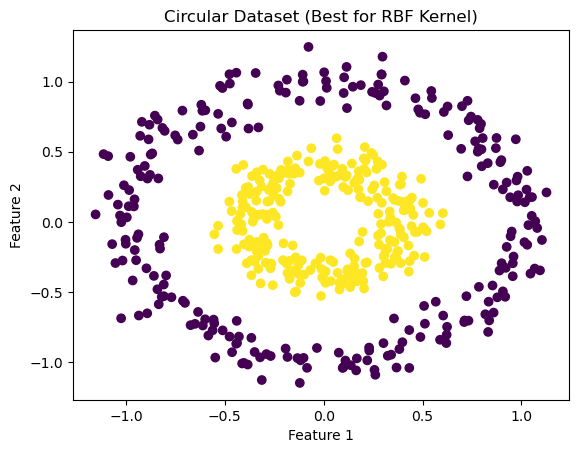

In [3]:
from sklearn.datasets import make_circles

# Generate circular dataset
X, y = make_circles(
    n_samples=500,
    noise=0.08,
    factor=0.4,
    random_state=42
)

# Plot dataset
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Circular Dataset (Best for RBF Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## XOR-like Dataset → Sigmoid Kernel

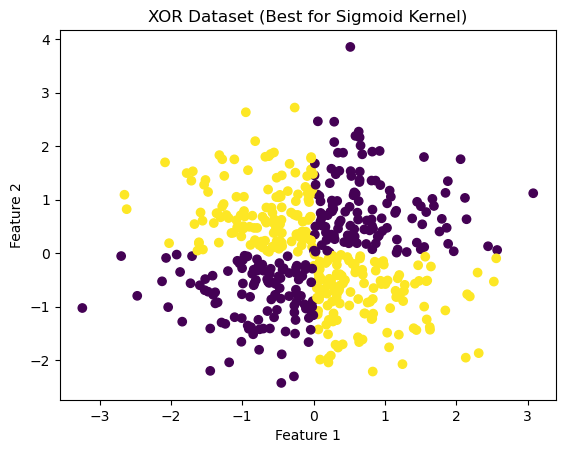

In [4]:
# Generate XOR-style dataset
np.random.seed(42)

X = np.random.randn(500, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)

# Plot dataset
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("XOR Dataset (Best for Sigmoid Kernel)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


### We will reuse this function for all kernels.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title):
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Predict on grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


## Linear

In [6]:
from sklearn.datasets import make_classification
from sklearn.svm import SVC

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    class_sep=2,
    random_state=42
)


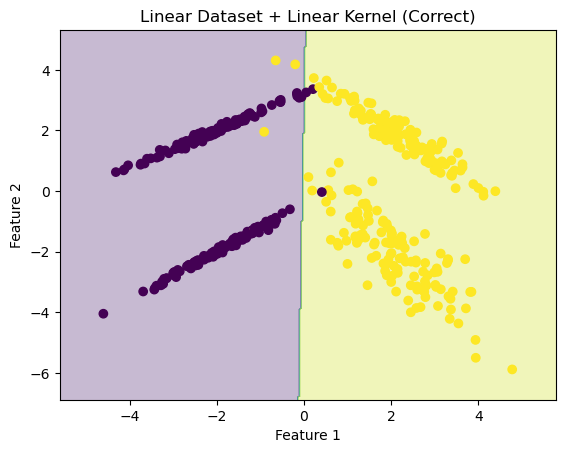

In [7]:
svm_linear = SVC(kernel="linear", C=1)
svm_linear.fit(X, y)

plot_decision_boundary(
    svm_linear, X, y,
    "Linear Dataset + Linear Kernel (Correct)"
)


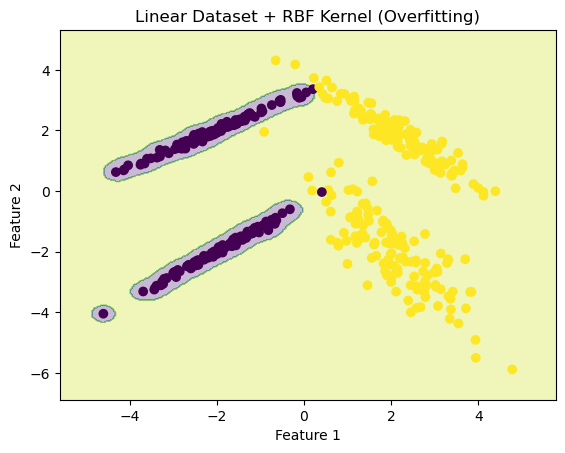

In [8]:
svm_wrong = SVC(kernel="rbf", gamma=10)
svm_wrong.fit(X, y)

plot_decision_boundary(
    svm_wrong, X, y,
    "Linear Dataset + RBF Kernel (Overfitting)"
)


## Polynomial

In [9]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=500, noise=0.15, random_state=42)


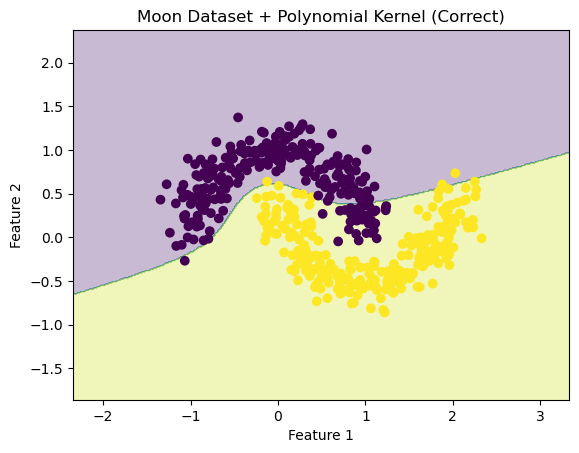

In [10]:
svm_poly = SVC(kernel="poly", degree=3, C=1)
svm_poly.fit(X, y)

plot_decision_boundary(
    svm_poly, X, y,
    "Moon Dataset + Polynomial Kernel (Correct)"
)


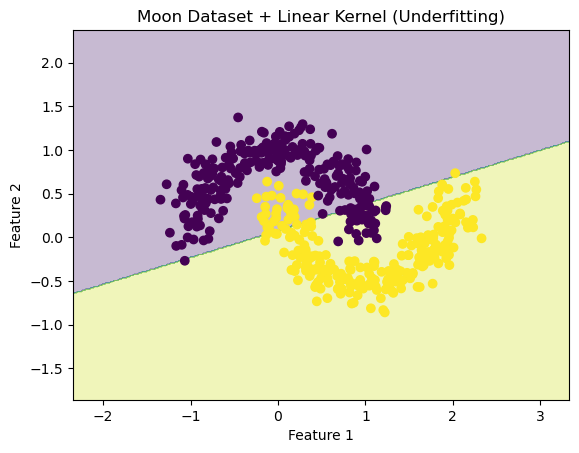

In [11]:
svm_wrong = SVC(kernel="linear", C=1)
svm_wrong.fit(X, y)

plot_decision_boundary(
    svm_wrong, X, y,
    "Moon Dataset + Linear Kernel (Underfitting)"
)


## RBF

In [12]:
from sklearn.datasets import make_circles

X, y = make_circles(
    n_samples=500,
    noise=0.08,
    factor=0.4,
    random_state=42
)


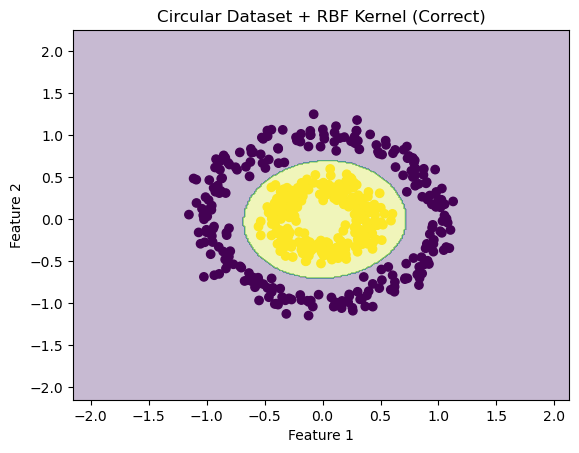

In [16]:
svm_rbf = SVC(kernel="rbf", gamma=1, C=1)
svm_rbf.fit(X, y)

plot_decision_boundary(
    svm_rbf, X, y,
    "Circular Dataset + RBF Kernel (Correct)"
)

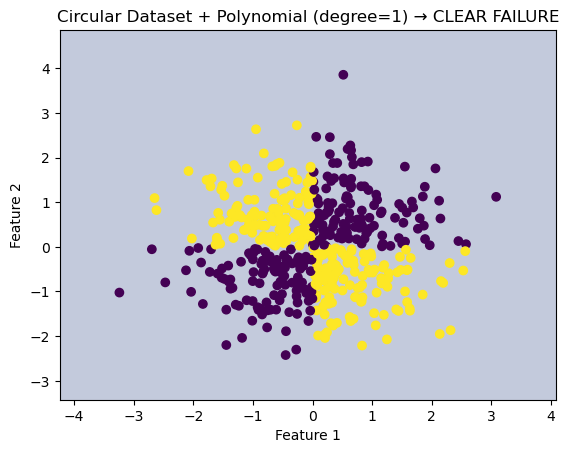

In [21]:
from sklearn.svm import SVC

svm_wrong = SVC(
    kernel="poly",
    degree=1,      # degree=1 makes it effectively linear
    coef0=0,
    C=0.1          # small C → underfitting
)

svm_wrong.fit(X, y)

plot_decision_boundary(
    svm_wrong,
    X,
    y,
    "Circular Dataset + Polynomial (degree=1) → CLEAR FAILURE"
)


## Sigmoid

In [18]:
np.random.seed(42)
X = np.random.randn(500, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)


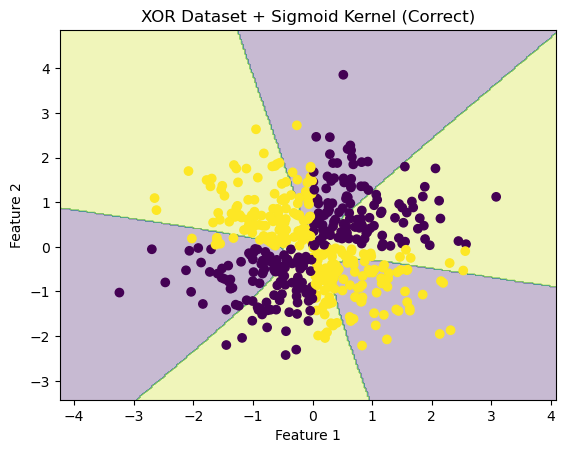

In [19]:
svm_sigmoid = SVC(kernel="sigmoid", C=1)
svm_sigmoid.fit(X, y)

plot_decision_boundary(
    svm_sigmoid, X, y,
    "XOR Dataset + Sigmoid Kernel (Correct)"
)


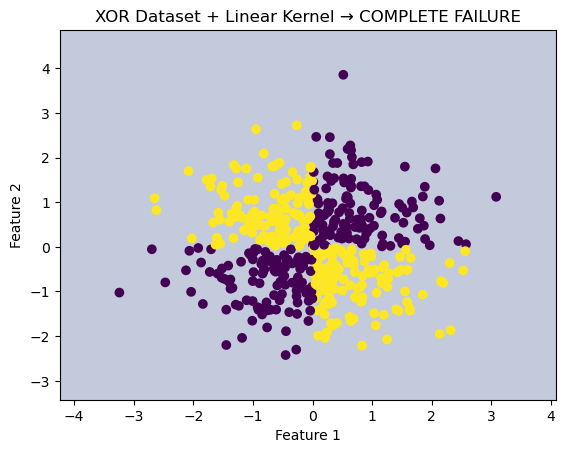

In [22]:
svm_wrong = SVC(
    kernel="linear",
    C=0.01          # extremely strict margin → no flexibility
)

svm_wrong.fit(X, y)

plot_decision_boundary(
    svm_wrong,
    X,
    y,
    "XOR Dataset + Linear Kernel → COMPLETE FAILURE"
)


## Model training

In [23]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns


In [24]:
# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print(X.shape)
print(y.value_counts())


(569, 30)
target
1    357
0    212
Name: count, dtype: int64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y   # VERY IMPORTANT in medical data
)


In [26]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

baseline_pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('svm', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [27]:
y_pred = baseline_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9824561403508771

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



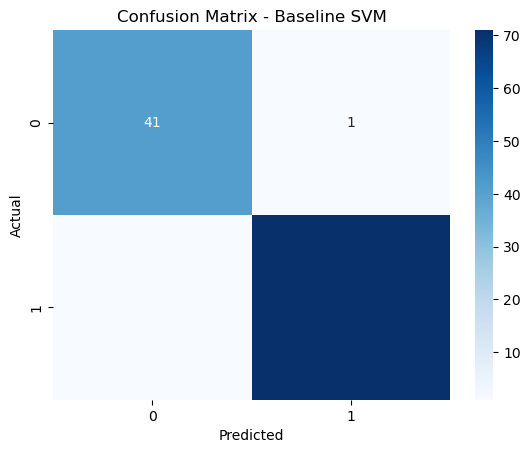

In [28]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline SVM")
plt.show()


In [29]:
param_grid = [
    {
        "svm__kernel": ["linear"],
        "svm__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1, 10, 100],
        "svm__gamma": [0.001, 0.01, 0.1, 1]
    },
    {
        "svm__kernel": ["poly"],
        "svm__C": [0.1, 1, 10],
        "svm__degree": [2, 3, 4]
    }
]


In [30]:
grid = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",   # better than accuracy for imbalance
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)


,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"[{'svm__C': [0.01, 0.1, ...], 'svm__kernel': ['linear']}, {'svm__C': [0.1, 1, ...], 'svm__gamma': [0.001, 0.01, ...], 'svm__kernel': ['rbf']}, ...]"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [31]:
print("Best Parameters:\n", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)


Best Parameters:
 {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best CV ROC-AUC: 0.9953560371517028


## With Feature selection

In [32]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


In [33]:
# Load dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

# Train-test split (industry standard)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [34]:
from sklearn.feature_selection import SelectKBest, f_classif


In [35]:
filter_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("svm", SVC(kernel="rbf"))
])


In [36]:
param_grid_filter = {
    "feature_selection__k": [5, 10, 15, 20],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.01, 0.1, 1]
}


In [37]:
grid_filter = GridSearchCV(
    estimator=filter_pipeline,
    param_grid=param_grid_filter,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_filter.fit(X_train, y_train)


,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'feature_selection__k': [5, 10, ...], 'svm__C': [0.1, 1, ...], 'svm__gamma': [0.01, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [38]:
best_filter_model = grid_filter.best_estimator_

y_pred = best_filter_model.predict(X_test)
y_score = best_filter_model.decision_function(X_test)

print("Best Parameters:", grid_filter.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'feature_selection__k': 20, 'svm__C': 1, 'svm__gamma': 0.1}
Accuracy: 0.9736842105263158
ROC-AUC: 0.9887566137566137

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [39]:
selected_mask = best_filter_model.named_steps["feature_selection"].get_support()
selected_features = X.columns[selected_mask]

print("Selected Features:\n", selected_features)


Selected Features:
 Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean compactness', 'mean concavity', 'mean concave points',
       'radius error', 'perimeter error', 'area error', 'concave points error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry'],
      dtype='object')


### FEATURE SELECTION – EMBEDDED METHOD

In [40]:
from sklearn.feature_selection import SelectFromModel


In [41]:
embedded_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectFromModel(
        estimator=SVC(kernel="linear", C=0.01)
    )),
    ("svm", SVC(kernel="rbf"))
])


In [42]:
param_grid_embedded = {
    "feature_selection__estimator__C": [0.001, 0.01, 0.1],
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.01, 0.1, 1]
}


In [43]:
grid_embedded = GridSearchCV(
    estimator=embedded_pipeline,
    param_grid=param_grid_embedded,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_embedded.fit(X_train, y_train)


,estimator,"Pipeline(step...svm', SVC())])"
,param_grid,"{'feature_selection__estimator__C': [0.001, 0.01, ...], 'svm__C': [0.1, 1, ...], 'svm__gamma': [0.01, 0.1, ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [44]:
best_embedded_model = grid_embedded.best_estimator_

y_pred = best_embedded_model.predict(X_test)
y_score = best_embedded_model.decision_function(X_test)

print("Best Parameters:", grid_embedded.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_score))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Parameters: {'feature_selection__estimator__C': 0.001, 'svm__C': 1, 'svm__gamma': 0.1}
Accuracy: 0.9736842105263158
ROC-AUC: 0.9871031746031746

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [45]:
selected_mask = best_embedded_model.named_steps["feature_selection"].get_support()
selected_features = X.columns[selected_mask]

print("Selected Features (Embedded):\n", selected_features)


Selected Features (Embedded):
 Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean concavity', 'mean concave points', 'radius error',
       'perimeter error', 'area error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry'],
      dtype='object')
